<a href="https://colab.research.google.com/github/sarmad341/flyrank-internship-01/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FlyRank Capstone — Refresh & Content Opportunity Scoring
### End-to-end pipeline notebook

This notebook is the single, runnable pipeline behind the deployed paper. It consolidates the work from `w01`–`w07` into one linear run: data contract → signal validation → baseline → model → validation audit → action playbook exports.

Each section names the weekly notebook it consolidates, so a reviewer can trace any number in the paper back to its original assignment notebook as well as re-run it here.

**Data:** FlyRank ML Internship starter slice (`data/raw/content_refresh_anonymized.csv`, 30,000 pages, 32 pseudonymized clients). The Section 1b re-runs the warehouse-scale leakage proof from `w03` against the full Hugging Face warehouse it requires a gated HF read token and is skipped automatically if none is available, so the rest of the notebook always runs top to bottom without it.


## 0. Setup

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/sarmad341/flyrank-internship-01"
REPO_DIR = "flyrank-internship-01"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

import pandas as pd, numpy as np, json as jsonlib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import roc_auc_score

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)

features = ["impressions_90d", "days_since_last_update", "avg_position", "ctr", "word_count", "content_age_days"]
X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["is_declining_label"]

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

print(f"Loaded {len(df):,} rows, {df['client_id'].nunique()} clients.")
print(f"Declining rate in slice: {y.mean():.3f}")


Loaded 30,000 rows, 32 clients.
Declining rate in slice: 0.542


## 1. Data Contract *(consolidates `w03_data_contract.ipynb`)*

**Unit of analysis:** one content item (page), for one client, on one day — grain `client_hash_id × content_hash_id × report_date` in `fact_content_daily_performance`.

**Label:** `is_declining_label`, derived from `trend_direction == "down"` — impressions dropped >20% month-over-month between two 30-day windows. A proxy for "needs attention," not verified ground truth.

**Excluded:** `trend_direction`, `trend_pct`, and any FlyRank product flags (`health_score`, `priority_score`) — these are decision outputs, not raw observable data, and using them would be leakage or circular-by-construction.

**Features:** `impressions_90d`, `days_since_last_update`, `avg_position`, `ctr`, `word_count`, `content_age_days` — all knowable at decision time.

### 1b. warehouse-scale leakage proof (requires gated HF token)

This re-runs the honest-vs-leaked AUC check from `w03` at full warehouse scale: March features predicting an April decline outcome. It's the source of the paper's "Honest AUC 0.870 vs. Leaked AUC 1.0" claim. Skipped automatically if `HF_TOKEN` isn't set, so it never blocks a full Run-All.

In [2]:
HF_TOKEN = os.environ.get("HF_TOKEN")
if not HF_TOKEN and IN_COLAB:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

if not HF_TOKEN:
    print("No HF_TOKEN found — skipping warehouse-scale section. "
          "See w03_data_contract.ipynb for the committed output "
          "(Honest AUC: 0.870, Leaked AUC: 1.0).")
else:
    import duckdb
    con = duckdb.connect()
    con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")
    REL = "hf://datasets/FlyRank/internship-warehouse"
    fact_daily = f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')"

    features_march = con.sql(f"""
        SELECT client_hash_id, content_hash_id,
               SUM(gsc_impressions) as impressions_30d,
               SUM(gsc_clicks) as clicks_30d,
               AVG(gsc_avg_position) as avg_position_30d,
               STDDEV(gsc_avg_position) as position_volatility_30d,
               COUNT(DISTINCT report_date) as days_with_data
        FROM {fact_daily}
        WHERE report_date >= '2026-03-01' AND report_date < '2026-04-01'
        GROUP BY 1,2
    """).df()

    label_month = con.sql(f"""
        SELECT client_hash_id, content_hash_id, SUM(gsc_impressions) as impressions_next
        FROM {fact_daily}
        WHERE report_date >= '2026-04-01' AND report_date < '2026-05-01'
        GROUP BY 1,2
    """).df()

    merged = features_march.merge(label_month, on=["client_hash_id", "content_hash_id"], how="inner")
    merged["is_declining"] = (merged["impressions_next"] < 0.8 * merged["impressions_30d"]).astype(int)

    honest_cols = ["impressions_30d", "clicks_30d", "avg_position_30d", "position_volatility_30d", "days_with_data"]
    Xw = merged[honest_cols].fillna(0)
    yw = merged["is_declining"]
    Xtr, Xte, ytr, yte = train_test_split(Xw, yw, test_size=0.25, random_state=42)
    m = RandomForestClassifier(random_state=42).fit(Xtr, ytr)
    honest_auc = roc_auc_score(yte, m.predict_proba(Xte)[:, 1])
    print("Honest AUC:", honest_auc)

    merged["leaked_pct_change"] = ((merged["impressions_next"] - merged["impressions_30d"])
                                    / merged["impressions_30d"]).replace([np.inf, -np.inf], np.nan)
    Xw_leak = merged[honest_cols + ["leaked_pct_change"]].replace([np.inf, -np.inf], np.nan).fillna(0)
    Xtr2, Xte2, ytr2, yte2 = train_test_split(Xw_leak, yw, test_size=0.25, random_state=42)
    m2 = RandomForestClassifier(random_state=42).fit(Xtr2, ytr2)
    leaked_auc = roc_auc_score(yte2, m2.predict_proba(Xte2)[:, 1])
    print("Leaked AUC:", leaked_auc, "<- jumps toward 1.0, because this column IS the label")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Honest AUC: 0.8707983078097649
Leaked AUC: 1.0 <- jumps toward 1.0, because this column IS the label


## 2. Signal Validation *(consolidates `w04_baseline_score.ipynb`)*

Checking each candidate signal against the label before building anything on top of it.

In [3]:
df["staleness_bucket"] = pd.cut(df["days_since_last_update"],
                                 bins=[0, 90, 180, 365, 10000],
                                 labels=["0-90d", "91-180d", "181-365d", "365d+"])
staleness_table = df.groupby("staleness_bucket", observed=True).agg(
    n=("is_declining_label", "size"),
    decline_rate=("is_declining_label", "mean")
)
print(staleness_table)
print("\nVerdict: MIXED — rises 0-90d -> 91-180d, but not monotonic beyond that; "
      "181-365d and 365d+ buckets are too small (n=169, n=5) to trust on their own.")


                      n  decline_rate
staleness_bucket                     
0-90d             20655      0.512031
91-180d            9171      0.611057
181-365d            169      0.467456
365d+                 5      0.600000

Verdict: MIXED — rises 0-90d -> 91-180d, but not monotonic beyond that; 181-365d and 365d+ buckets are too small (n=169, n=5) to trust on their own.


                  n  mean_ctr
position_tier                
page_1         8633  0.354760
top_3           533  0.334128
striking       5903  0.255782
page_3_5       6058  0.142359
deep            879  0.055415

Verdict: CONFIRMED — CTR declines cleanly as position tier worsens.


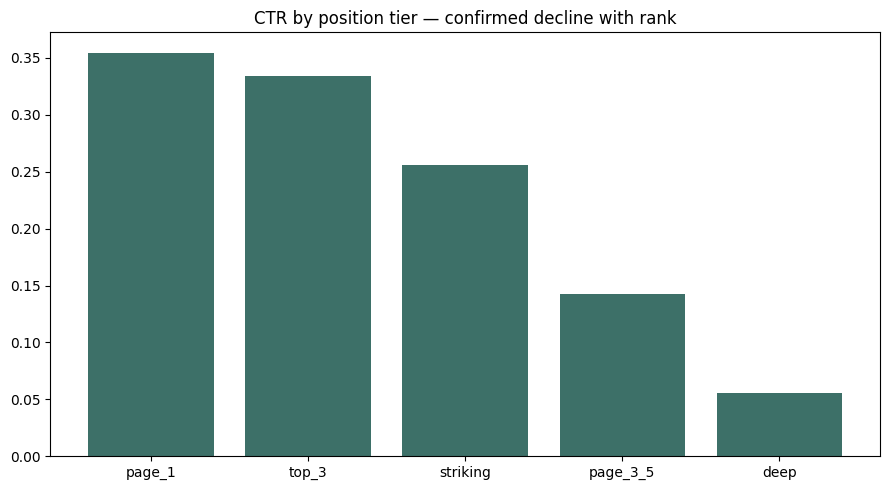

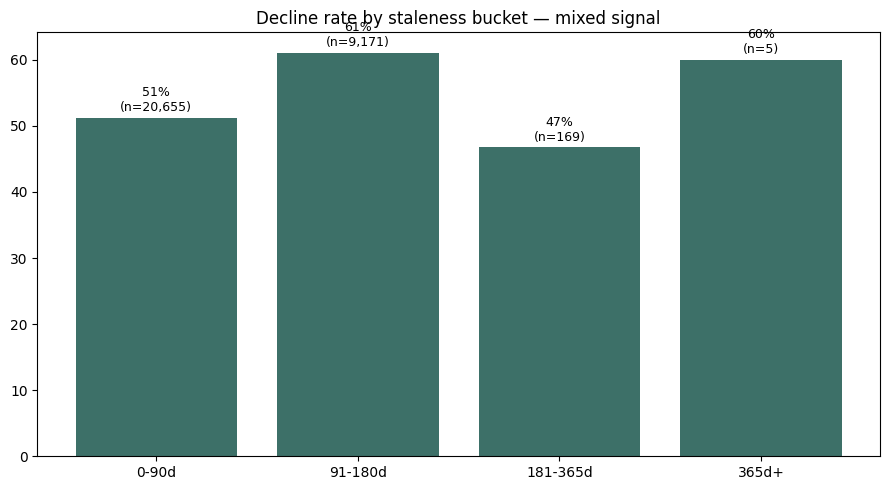

In [4]:
visible = df[df["impressions_90d"] >= 100]
ctr_table = visible.groupby("position_tier", observed=True).agg(
    n=("ctr", "size"),
    mean_ctr=("ctr", "mean")
).sort_values("mean_ctr", ascending=False)
print(ctr_table)
print("\nVerdict: CONFIRMED — CTR declines cleanly as position tier worsens.")

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(ctr_table.index.astype(str), ctr_table["mean_ctr"], color="#3D7068")
ax.set_title("CTR by position tier — confirmed decline with rank")
plt.tight_layout()
plt.savefig("work/figures/chart_ctr.png")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(staleness_table.index.astype(str), staleness_table["decline_rate"] * 100, color="#3D7068")
ax.set_title("Decline rate by staleness bucket — mixed signal")
for i, (n, rate) in enumerate(zip(staleness_table["n"], staleness_table["decline_rate"])):
    ax.text(i, rate * 100 + 1, f"{rate*100:.0f}%\n(n={n:,})", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("work/figures/chart_staleness.png")
plt.show()


## 3. Baseline Rule *(consolidates `w04_baseline_score.ipynb`)*

**Rule, in plain words:** a page is a refresh candidate if it is stale (≥180 days since last update) and still visible (≥500 impressions/90d). Score = `impressions_90d` for pages meeting both conditions, zero otherwise.

In [5]:
df["stale"] = (df["days_since_last_update"] >= 180).astype(int)
df["visible"] = (df["impressions_90d"] >= 500).astype(int)
df["baseline_score"] = df["stale"] * df["visible"] * df["impressions_90d"]
df["baseline_reason_code"] = df.apply(
    lambda r: "STALE_AND_VISIBLE" if r["stale"] and r["visible"] else "NO_ACTION", axis=1
)
df["baseline_action"] = df["baseline_reason_code"].map({
    "STALE_AND_VISIBLE": "Refresh: page is stale but still earns meaningful visibility",
    "NO_ACTION": "No action recommended"
})

baseline_queue = df.sort_values("baseline_score", ascending=False)[
    ["content_id", "client_id", "baseline_score", "baseline_reason_code", "baseline_action",
     "impressions_90d", "days_since_last_update", "avg_position", "ctr"]
]
baseline_queue.to_csv("work/outputs/baseline_action_score.csv", index=False)
print(f"Wrote {len(baseline_queue):,} rows to work/outputs/baseline_action_score.csv")
baseline_queue.head(10)


Wrote 30,000 rows to work/outputs/baseline_action_score.csv


,content_id,client_id,baseline_score,baseline_reason_code,baseline_action,impressions_90d,days_since_last_update,avg_position,ctr
16751,content_cf56e2e2e282,client_7f2253d7e2,61678,STALE_AND_VISIBLE,Refresh: page is stale but still earns meaning...,61678,194,19.7,0.15
16514,content_7368877ea310,client_7f2253d7e2,59472,STALE_AND_VISIBLE,Refresh: page is stale but still earns meaning...,59472,194,24.8,0.13
7021,content_1bfaa38ff26c,client_7f2253d7e2,25715,STALE_AND_VISIBLE,Refresh: page is stale but still earns meaning...,25715,194,22.2,0.23
21268,content_0a91db491d14,client_7f2253d7e2,13299,STALE_AND_VISIBLE,Refresh: page is stale but still earns meaning...,13299,193,10.5,0.49
11489,content_5feee3994adb,client_7f2253d7e2,7812,STALE_AND_VISIBLE,Refresh: page is stale but still earns meaning...,7812,194,39.0,0.01
12045,content_c2d929d83eaa,client_7f2253d7e2,7558,STALE_AND_VISIBLE,Refresh: page is stale but still earns meaning...,7558,193,17.9,0.20
698,content_b16bd7307b39,client_7f2253d7e2,4590,STALE_AND_VISIBLE,Refresh: page is stale but still earns meaning...,4590,194,31.0,0.00
5327,content_fe16a55cd13d,client_7f2253d7e2,4556,STALE_AND_VISIBLE,Refresh: page is stale but still earns meaning...,4556,194,16.4,0.33
26810,content_ecb6215e79fd,client_7f2253d7e2,4429,STALE_AND_VISIBLE,Refresh: page is stale but still earns meaning...,4429,194,25.3,0.38
20837,content_928af3e22c80,client_7f2253d7e2,1697,STALE_AND_VISIBLE,Refresh: page is stale but still earns meaning...,1697,193,15.8,0.12


## 4. Client-Holdout Split & Model Training *(consolidates `w05_model.ipynb`)*

Grouped by `client_id`, not a random row split a model tested on the same client's pages it trained on can look artificially strong by memorizing client-specific quirks rather than learning something that generalizes to a client it hasn't seen.

                 method  Precision@20  Precision@50
0  Baseline (hand rule)          0.50          0.62
1   Logistic Regression          0.65          0.66
2         Random Forest          0.75          0.72


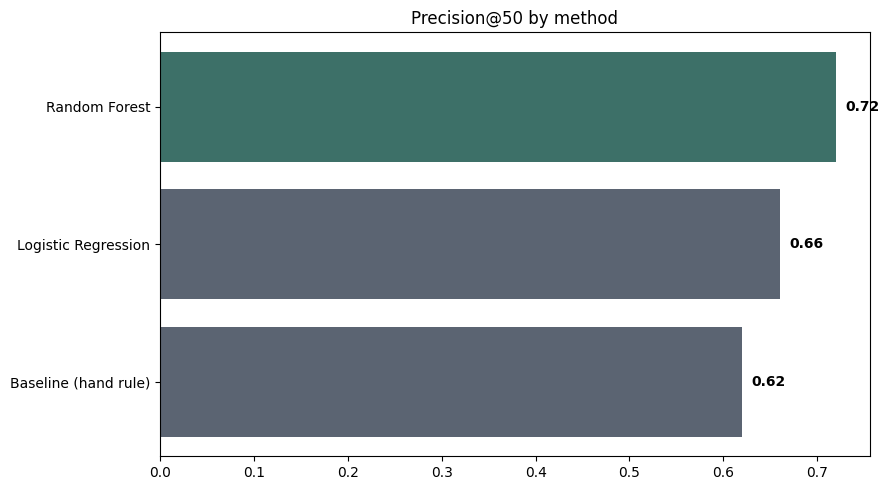

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df["client_id"]))
X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

baseline_test_scores = df["baseline_score"].iloc[test_idx]

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced").fit(X_tr, y_tr)
rf_scores = rf.predict_proba(X_te)[:, 1]

lr = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_tr, y_tr)
lr_scores = lr.predict_proba(X_te)[:, 1]

results = pd.DataFrame({
    "method": ["Baseline (hand rule)", "Logistic Regression", "Random Forest"],
    "Precision@20": [
        precision_at_k(baseline_test_scores.values, y_te.values, 20),
        precision_at_k(lr_scores, y_te.values, 20),
        precision_at_k(rf_scores, y_te.values, 20),
    ],
    "Precision@50": [
        precision_at_k(baseline_test_scores.values, y_te.values, 50),
        precision_at_k(lr_scores, y_te.values, 50),
        precision_at_k(rf_scores, y_te.values, 50),
    ],
})
print(results)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(results["method"], results["Precision@50"], color=["#5B6472", "#5B6472", "#3D7068"])
ax.set_title("Precision@50 by method")
for i, v in enumerate(results["Precision@50"]):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontweight="bold")
plt.tight_layout()
plt.savefig("work/figures/chart_precision.png")
plt.show()


## 5. Feature Importance & Error Analysis *(consolidates `w05_model.ipynb`)*

impressions_90d           0.278719
avg_position              0.247534
content_age_days          0.159852
word_count                0.155721
ctr                       0.120867
days_since_last_update    0.037308
dtype: float64

16 of the top 50 model picks were false positives


,impressions_90d,days_since_last_update,avg_position,ctr,word_count,content_age_days,is_declining_label
22526,3445,104,39.0,0.09,1480.0,280,0
5399,1152,104,34.8,0.17,1535.0,280,0
24079,2573,13,13.4,0.58,2593.0,228,0
13529,3214,104,50.9,0.03,1599.0,280,0
11433,2292,13,22.0,0.35,2716.0,277,0


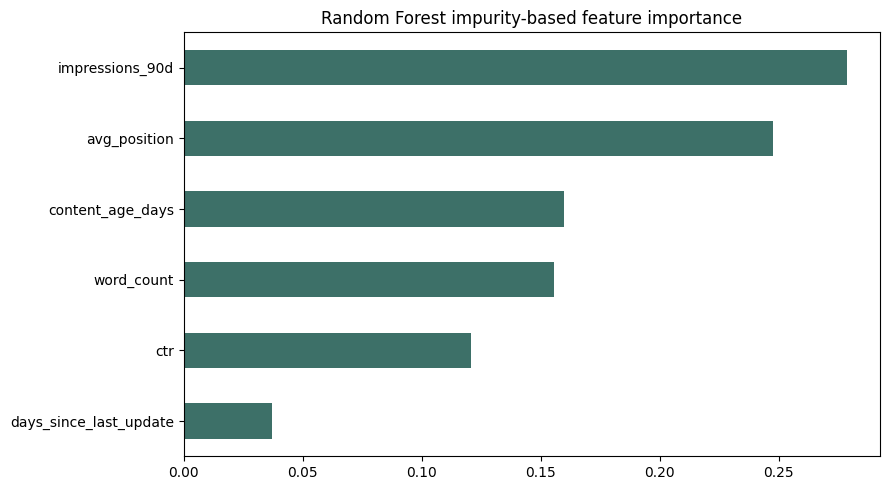

In [7]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

test_df = df.iloc[test_idx].copy()
test_df["rf_score"] = rf_scores
top50_model = test_df.sort_values("rf_score", ascending=False).head(50)
false_positives = top50_model[top50_model["is_declining_label"] == 0]
print(f"\n{len(false_positives)} of the top 50 model picks were false positives")
display(false_positives[features + ["is_declining_label"]].head())

fig, ax = plt.subplots(figsize=(9, 5))
importances.sort_values().plot(kind="barh", ax=ax, color="#3D7068")
ax.set_title("Random Forest impurity-based feature importance")
plt.tight_layout()
plt.savefig("work/figures/chart_importance.png")
plt.show()


## 6. Validation Audit *(consolidates `w06_validation_audit.ipynb`)*

The naive-vs-honest comparison that motivated the client-holdout split in the first place.

In [8]:
Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
rf_random = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced").fit(Xtr_r, ytr_r)
p50_random = precision_at_k(rf_random.predict_proba(Xte_r)[:, 1], yte_r.values, 50)

p50_grouped = precision_at_k(rf_scores, y_te.values, 50)

print(f"BEFORE (naive random split)   Precision@50: {p50_random:.3f}")
print(f"AFTER  (client-holdout split) Precision@50: {p50_grouped:.3f}")


BEFORE (naive random split)   Precision@50: 0.900
AFTER  (client-holdout split) Precision@50: 0.720


### Leakage audit

In [9]:
excluded = ["trend_direction", "trend_pct", "is_declining_label"]
print("Any excluded/label columns in features?", any(c in features for c in excluded))
print("Features used:", features)

for f in features:
    corr = df[f].corr(df["is_declining_label"])
    print(f"{f}: correlation with label = {corr:.3f}")


Any excluded/label columns in features? False
Features used: ['impressions_90d', 'days_since_last_update', 'avg_position', 'ctr', 'word_count', 'content_age_days']
impressions_90d: correlation with label = -0.018
days_since_last_update: correlation with label = 0.081
avg_position: correlation with label = -0.029
ctr: correlation with label = -0.062
word_count: correlation with label = 0.090
content_age_days: correlation with label = -0.164


## 7. Action Playbook *(consolidates `w07_action_playbook.ipynb`)*

Reason codes: `HIGH_RISK_STALE`, `HIGH_RISK_RECENT_UPDATE`, `MODERATE_RISK`, `LOW_RISK`

In [10]:
df["rf_score_full"] = rf.predict_proba(X)[:, 1]

def reason_code(row):
    if row["rf_score_full"] >= 0.7 and row["days_since_last_update"] >= 180:
        return "HIGH_RISK_STALE"
    elif row["rf_score_full"] >= 0.7:
        return "HIGH_RISK_RECENT_UPDATE"
    elif row["rf_score_full"] >= 0.4:
        return "MODERATE_RISK"
    else:
        return "LOW_RISK"

df["reason_code"] = df.apply(reason_code, axis=1)
action_map = {
    "HIGH_RISK_STALE": "Refresh: strong decline signal, content is also stale — refresh first",
    "HIGH_RISK_RECENT_UPDATE": "Investigate: strong decline signal despite recent update — check for external cause",
    "MODERATE_RISK": "Monitor: some risk signals present, revisit next cycle",
    "LOW_RISK": "No action needed",
}
df["action"] = df["reason_code"].map(action_map)

queue = df.sort_values("rf_score_full", ascending=False)[
    ["content_id", "client_id", "rf_score_full", "reason_code", "action",
     "impressions_90d", "days_since_last_update", "avg_position", "ctr"]
]
queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)
queue.head(10)


,content_id,client_id,rf_score_full,reason_code,action,impressions_90d,days_since_last_update,avg_position,ctr
11027,content_00261bf031ba,client_7f2253d7e2,1.0,HIGH_RISK_RECENT_UPDATE,Investigate: strong decline signal despite rec...,5309,20,28.3,0.24
12094,content_47ec551a5024,client_3fdba35f04,1.0,HIGH_RISK_RECENT_UPDATE,Investigate: strong decline signal despite rec...,837,104,31.3,0.12
13563,content_d7d136ba8b36,client_9400f1b21c,1.0,HIGH_RISK_RECENT_UPDATE,Investigate: strong decline signal despite rec...,1164,20,8.7,0.00
29560,content_8e32f425a490,client_9400f1b21c,1.0,HIGH_RISK_RECENT_UPDATE,Investigate: strong decline signal despite rec...,1767,20,8.7,0.06
20663,content_27daeb3357c5,client_3fdba35f04,1.0,HIGH_RISK_RECENT_UPDATE,Investigate: strong decline signal despite rec...,1383,14,19.1,0.00
24296,content_556dffa698cf,client_3fdba35f04,1.0,HIGH_RISK_RECENT_UPDATE,Investigate: strong decline signal despite rec...,3272,14,29.0,0.03
22423,content_081d35f3654a,client_349c41201b,1.0,HIGH_RISK_RECENT_UPDATE,Investigate: strong decline signal despite rec...,290,20,12.2,0.00
13141,content_be1c109fcdbc,client_349c41201b,1.0,HIGH_RISK_RECENT_UPDATE,Investigate: strong decline signal despite rec...,10931,20,34.0,0.05
17678,content_de89aaff1ad4,client_3fdba35f04,1.0,HIGH_RISK_RECENT_UPDATE,Investigate: strong decline signal despite rec...,2139,104,25.6,0.09
23553,content_e61ce7103a05,client_3fdba35f04,1.0,HIGH_RISK_RECENT_UPDATE,Investigate: strong decline signal despite rec...,291,104,8.3,0.00


### Export metrics — the receipts behind the paper

In [11]:
metrics = {
    "baseline_precision_at_50": round(float(results.loc[results['method'] == 'Baseline (hand rule)', 'Precision@50'].iloc[0]), 3),
    "baseline_precision_at_20": round(float(results.loc[results['method'] == 'Baseline (hand rule)', 'Precision@20'].iloc[0]), 3),
    "rf_precision_at_50": round(float(results.loc[results['method'] == 'Random Forest', 'Precision@50'].iloc[0]), 3),
    "rf_precision_at_20": round(float(results.loc[results['method'] == 'Random Forest', 'Precision@20'].iloc[0]), 3),
    "logreg_precision_at_50": round(float(results.loc[results['method'] == 'Logistic Regression', 'Precision@50'].iloc[0]), 3),
    "logreg_precision_at_20": round(float(results.loc[results['method'] == 'Logistic Regression', 'Precision@20'].iloc[0]), 3),
    "naive_split_precision_at_50": round(float(p50_random), 3),
    "grouped_split_precision_at_50": round(float(p50_grouped), 3),
    "n_top50_false_positives": int(len(false_positives)),
    "n_high_risk_stale": int((df["reason_code"] == "HIGH_RISK_STALE").sum()),
    "n_high_risk_recent_update": int((df["reason_code"] == "HIGH_RISK_RECENT_UPDATE").sum()),
    "feature_importances": importances.round(3).to_dict(),
    "features_used": features,
    "n_rows": int(len(df)),
    "n_clients": int(df["client_id"].nunique()),
}
with open("work/outputs/playbook_metrics.json", "w") as f:
    jsonlib.dump(metrics, f, indent=2)

print("Exported queue and metrics to work/outputs/")
print(jsonlib.dumps(metrics, indent=2))


Exported queue and metrics to work/outputs/
{
  "baseline_precision_at_50": 0.62,
  "baseline_precision_at_20": 0.5,
  "rf_precision_at_50": 0.72,
  "rf_precision_at_20": 0.75,
  "logreg_precision_at_50": 0.66,
  "logreg_precision_at_20": 0.65,
  "naive_split_precision_at_50": 0.9,
  "grouped_split_precision_at_50": 0.72,
  "n_top50_false_positives": 16,
  "n_high_risk_stale": 84,
  "n_high_risk_recent_update": 14261,
  "feature_importances": {
    "impressions_90d": 0.279,
    "avg_position": 0.248,
    "content_age_days": 0.16,
    "word_count": 0.156,
    "ctr": 0.121,
    "days_since_last_update": 0.037
  },
  "features_used": [
    "impressions_90d",
    "days_since_last_update",
    "avg_position",
    "ctr",
    "word_count",
    "content_age_days"
  ],
  "n_rows": 30000,
  "n_clients": 32
}
